# Notebook 02 - Baseline Experiments with SageMaker MLflow App

**Module:** ITI113 Machine Learning and Operations

**Focus Area:** B - Model Development, plus C - MLOps, Experiment Tracking

---

### What this notebook does

This notebook runs team03's baseline experiments using the SageMaker MLflow App.

1. Connects to team03's SageMaker MLflow App and validates the TeamId tag
2. Logistic Regression baseline, logging params, metrics, plots and model artifacts to MLflow
3. Logistic Regression hyperparameter tuning with nested child runs
4. Random Forest baseline, logging params, metrics, feature importance and model artifacts
5. Random Forest hyperparameter tuning with nested child runs
6. Programmatic run comparison and best-model selection against a quality gate
7. Saves best_model.json with the winning run's details


### Summary of Key Findings

- Logistic regression baseline passes the 0.85 quality gate at 0.8898 test AUC-ROC
- Tuning C and penalty for logistic regression only nudges performance up to 0.8908 test AUC (C = 10.0, L2), a small gain over baseline, and very low C (0.01) collapses to 0.701 AUC
- Random Forest baseline misses the quality gate at 0.8446 test AUC and catches only 56.35% of scams despite high precision (86.0%)
- Tuning Random Forest (200 estimators, depth 8) lifts it to 0.86 test AUC, just above the gate, but recall only reaches 52.18%, still far behind logistic regression
- Logistic regression is the overall winner: lr_candidate_04 (C = 10.0, L2) is registered as the best model at 0.8908 test AUC

In [1]:
%%capture
%pip install --upgrade "sagemaker>=2,<3" boto3 botocore
%pip install --upgrade mlflow sagemaker-mlflow
print("Packages installed.")

## 0. Configuration

Sets team, student and project identifiers, resolves the MLflow App config file for this workspace, and defines the quality gate threshold used later in this notebook.


In [2]:
import os
import json
import logging
import warnings
from pathlib import Path

os.environ["SAGEMAKER_SUPPRESS_V2_WARNING"] = "1"
warnings.filterwarnings("ignore")
logging.getLogger("sagemaker.config").setLevel(logging.WARNING)

import boto3
import sagemaker

session = sagemaker.Session()
role = sagemaker.get_execution_role()

TEAM_ID = "team03"
STUDENT_ID = "s301"
COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "crypto-scam-detector"
REGION = "ap-southeast-1"
BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"
QUALITY_GATE = 0.85

# MLflow App config, checks for a team-level config file, then a student-specific one
TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_app_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = mlflow_app_config.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = mlflow_app_config.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# Fallback
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:"
    "mlflow-app/app-J5AYUG4AJHVW"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present
config_team_id = mlflow_app_config.get("TEAM_ID") or mlflow_app_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

print("ITI113 Baseline Experiments, SageMaker MLflow App")
print(f"Team: {TEAM_ID}")
print(f"Student: {STUDENT_ID}")
print(f"S3 Prefix: {PREFIX}")
print(f"MLflow App ARN: {MLFLOW_APP_ARN}")
print(f"MLflow Experiment: {MLFLOW_EXPERIMENT}")
print(f"Registered Model: {REGISTERED_MODEL}")
print(f"Quality gate (AUC): {QUALITY_GATE}")
print(f"SageMaker Role: {role}")

Loaded MLflow App config from mlflow_app_config_team03_s301.json
ITI113 Baseline Experiments, SageMaker MLflow App
Team: team03
Student: s301
S3 Prefix: iti113/team03/data/crypto-scam-detector
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW
MLflow Experiment: ITI113/team03/Experiment1
Registered Model: iti113-team03-crypto-scam-detector
Quality gate (AUC): 0.85
SageMaker Role: arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team03


## 1. Connect to SageMaker MLflow App

Validates that the configured MLflow App belongs to this team before setting it as the active tracking backend for all runs logged below.


In [3]:
import mlflow
import boto3

sm_client = boto3.client("sagemaker", region_name=REGION)

# Safety check: the selected MLflow App must have ResourceTag/TeamId = TEAM_ID
try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# Tag every run with the dataset version, sha256 of the raw CSV's pointer file
try:
    _pointer_obj = boto3.client("s3", region_name=REGION).get_object(
        Bucket=BUCKET, Key=f"{PREFIX}/raw/_latest.json"
    )
    _dataset_pointer = json.loads(_pointer_obj["Body"].read())
    DATASET_VERSION = (_dataset_pointer.get("sha256") or "unknown")[:12]
except Exception as _e:
    print(f"[WARNING] Could not read dataset pointer file, falling back to 'unknown': {type(_e).__name__} {_e}")
    DATASET_VERSION = "unknown"

print(f"Dataset version tag (sha256[:12]): {DATASET_VERSION}")

# RUN_SESSION_ID: a unique tag for this notebook execution
import uuid
from datetime import datetime, timezone

RUN_SESSION_ID = f"{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}-{uuid.uuid4().hex[:8]}"
print(f"Run session ID: {RUN_SESSION_ID}")

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,
    "student": STUDENT_ID,
    "dataset": PROJECT_NAME,
    "dataset_sha256": DATASET_VERSION,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
    "run_session_id": RUN_SESSION_ID,
}

print(f"\nTracking URI: {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment: {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

# Generate a presigned UI URL if the current role has permission.
try:
    url_response = sm_client.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN
    )
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)

MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-gpdrdk2w4dgw
  ProjectName: crypto-scam-detector
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-gpdrdk2w4dgw/team03-shared
  Course: ITI113
  TeamId: team03
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: s301
[OK] MLflow App tag TeamId=team03 matches notebook TEAM_ID=team03
Dataset version tag (sha256[:12]): 31e13ac65ebc
Run session ID: 20260819T081140Z-2de14720

Tracking URI: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW
Experiment: ITI113/team03/Experiment1
Experiment ID: 1


## 2. Load Processed Data

This cell loads train.csv, test.csv and tfidf_vectorizer.joblib from S3 at {PREFIX}/processed/. This keeps this notebook self-contained, with no utils import needed, and guarantees the exact same train/test split and TF-IDF vectorizer already computed upstream, instead of risking a second, independently randomised split. y_train and y_test are binarised here, with 1 meaning scam, so the rest of this notebook's metric and plotting code, written for a 0/1 target.


In [4]:
import io
import tempfile

import pandas as pd, numpy as np
import scipy.sparse as sp
import joblib

SCAM_LABEL = "scam"

s3 = boto3.client("s3")
PROCESSED_PREFIX = f"{PREFIX}/processed"

def load_csv_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

def load_joblib_from_s3(bucket, key):
    with tempfile.NamedTemporaryFile(suffix=".joblib") as tmp:
        s3.download_file(bucket, key, tmp.name)
        return joblib.load(tmp.name)

train_df = load_csv_from_s3(BUCKET, f"{PROCESSED_PREFIX}/train.csv")
test_df = load_csv_from_s3(BUCKET, f"{PROCESSED_PREFIX}/test.csv")
vectorizer = load_joblib_from_s3(BUCKET, f"{PROCESSED_PREFIX}/tfidf_vectorizer.joblib")

print(f"Loaded processed data from s3://{BUCKET}/{PROCESSED_PREFIX}/")

engineered_cols = [
    "urgency_keyword_count", "guaranteed_return_keyword_count", "countdown_phrase_count",
    "exclamation_count", "urgency_score", "has_wallet_address",
    "has_url", "url_count", "has_email", "has_phone_number", "payment_keyword_count",
    "off_platform_keyword_count", "credential_keyword_count",
    "capital_letter_ratio", "has_numeric_content",
]

X_train_tfidf = vectorizer.transform(train_df["clean_text"])
X_test_tfidf = vectorizer.transform(test_df["clean_text"])

X_train = sp.hstack([X_train_tfidf, train_df[engineered_cols].values]).tocsr()
X_test = sp.hstack([X_test_tfidf, test_df[engineered_cols].values]).tocsr()

FEATURE_NAMES = list(vectorizer.get_feature_names_out()) + engineered_cols

y_train = (train_df["label"] == SCAM_LABEL).astype(int)
y_test = (test_df["label"] == SCAM_LABEL).astype(int)

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test: {X_test.shape[0]} rows')

Loaded processed data from s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/
Train: 8372 rows, 5015 features
Test: 2094 rows


## 3. Helper Functions

Reusable logging helpers so every run captures identical metrics and artifacts.


In [5]:
import matplotlib.pyplot as plt, tempfile, mlflow.sklearn
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay)

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    metrics = {}
    for split, X, y in [('train',X_tr,y_tr),('test',X_te,y_te)]:
        yp = model.predict(X)
        yb = model.predict_proba(X)[:,1]
        metrics.update({
            f'{split}_accuracy' : round(accuracy_score(y,yp),4),
            f'{split}_f1'       : round(f1_score(y,yp),4),
            f'{split}_precision': round(precision_score(y,yp),4),
            f'{split}_recall'   : round(recall_score(y,yp),4),
            f'{split}_auc_roc'  : round(roc_auc_score(y,yb),4),
        })
    return metrics

def log_confusion_matrix(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_estimator(
        model, X_te, y_te,
        display_labels=['Legitimate','Scam'], cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/confusion_matrix.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

def log_roc_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5,4))
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax)
    ax.plot([0,1],[0,1],'k--', label='Random baseline')
    ax.set_title(f'ROC Curve — {title}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/roc_curve.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

def log_feature_importance(model, feature_names, title, top_n=5):
    if not hasattr(model,'feature_importances_'): return
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    imp = imp.tail(top_n)
    fig, ax = plt.subplots(figsize=(6,7))
    imp.plot(kind='barh', ax=ax, color='#5B9BD5')
    ax.set_title(f'Feature Importance (top {top_n}) — {title}', fontweight='bold')
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/feature_importance.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

## 4. Logistic Regression Baseline

The simplest model that makes sense for binary classification.


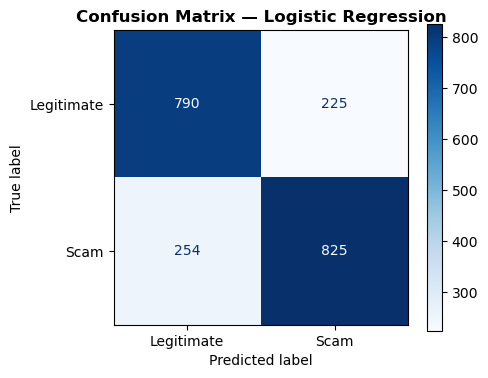

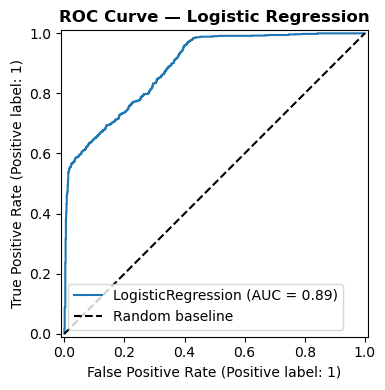

🏃 View run team03_s301_logistic_regression_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3bc650c2f6344811a234d4a131179562
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
LOGISTIC REGRESSION RESULTS
  TEST test_accuracy: 0.7713
  TEST test_auc_roc: 0.8898
  TEST test_f1: 0.775
  TEST test_precision: 0.7857
  TEST test_recall: 0.7646
  TRAIN train_accuracy: 0.8164
  TRAIN train_auc_roc: 0.9199
  TRAIN train_f1: 0.8186
  TRAIN train_precision: 0.8342
  TRAIN train_recall: 0.8035
Run ID: 3bc650c2f6344811a234d4a131179562


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline"

LR_PARAMS = {'C':1.0, 'max_iter':1000, 'solver':'lbfgs', 'random_state':RANDOM_STATE}

with mlflow.start_run(run_name=run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({**LR_PARAMS, 'model_type':'LogisticRegression',
                       'n_features':X_train.shape[1], 'train_size':X_train.shape[0]})

    lr = LogisticRegression(**LR_PARAMS)
    lr.fit(X_train, y_train)

    metrics = evaluate_model(lr, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(lr, X_test, y_test, 'Logistic Regression')
    log_roc_curve(lr, X_test, y_test, 'Logistic Regression')
    mlflow.sklearn.log_model(lr, name ='model')
    LR_RUN_ID = run.info.run_id

print('LOGISTIC REGRESSION RESULTS')
for k, v in sorted(metrics.items()):
    split = 'TRAIN' if k.startswith('train') else 'TEST'
    print(f'  {split} {k}: {v}')
print(f'Run ID: {LR_RUN_ID}')

**Key finding:** The logistic regression baseline reaches 0.8898 test AUC-ROC with 77.13% accuracy and 76.46% recall, still above the 0.85 quality gate. Precision at 78.57% and recall at 76.46%.

## 5. Logistic Regression Hyperparameter Tuning

Sweeps regularization strength C and penalty type, since these are the parameters that matter most for a TF-IDF feature space.


In [7]:
from sklearn.linear_model import LogisticRegression

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 0.1,   'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 1.0,   'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 10.0,  'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 1.0,   'penalty': 'l1', 'solver': 'liblinear'},
    {'C': 10.0,  'penalty': 'l1', 'solver': 'liblinear'}
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_lr_auc, best_lr_model, best_lr_params = 0, None, None

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_lr_tuning_parent") as lr_parent:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_param('n_candidates', len(lr_param_grid))
    mlflow.log_param('cv_folds', 5)

    for i, params in enumerate(lr_param_grid):
        all_p = {**params, 'max_iter': 1000, 'class_weight': 'balanced', 'random_state': RANDOM_STATE}
        with mlflow.start_run(run_name=f'lr_candidate_{i+1:02d}', nested=True):
            
            mlflow.set_tags(COMMON_TAGS)
            mlflow.log_params(all_p)
            m = LogisticRegression(**all_p)
            cv_scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
            mlflow.log_metric('cv_auc_mean', round(cv_scores.mean(), 4))
            mlflow.log_metric('cv_auc_std',  round(cv_scores.std(), 4))
            m.fit(X_train, y_train)
            test_m = evaluate_model(m, X_train, y_train, X_test, y_test)
            mlflow.log_metrics(test_m)
            mlflow.sklearn.log_model(m, name="model")

            print(f'Candidate {i+1}: {params} | CV AUC={cv_scores.mean():.4f} | Test AUC={test_m["test_auc_roc"]}')
            if cv_scores.mean() > best_lr_auc:
                best_lr_auc, best_lr_model, best_lr_params = cv_scores.mean(), m, all_p

    mlflow.log_metric('best_cv_auc', round(best_lr_auc, 4))
    LR_TUNING_RUN_ID = lr_parent.info.run_id

print(f'\nBest CV AUC: {best_lr_auc:.4f}')
print(f'Best params: {best_lr_params}')

Candidate 1: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.6896 | Test AUC=0.701
🏃 View run lr_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/910b98137d644f6ca44424c370555903
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 2: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.8318 | Test AUC=0.86
🏃 View run lr_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/bdf771d02c71472094ce3473aa0f9aba
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 3: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.8830 | Test AUC=0.8899
🏃 View run lr_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/99b520b7ce4b4ef19b321a24c114d910
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 4: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'} | 

**Key finding:** Sweeping C and penalty type across six candidates now favours the largest C tested, 10.0 with an L2 penalty, reaching 0.8857 cross-validated AUC and 0.8908 test AUC, only a small step above the baseline's 0.8898. The smallest C, 0.01, collapses to 0.701 test AUC on this dataset, an even sharper drop than seen previously, showing the model needs more regularisation headroom than the baseline default to fit the harder decision boundary. Since the best candidate only edges past the baseline by a small margin, tuning recovers a little performance but does not fundamentally change the picture.


## 6. Random Forest Baseline

An ensemble model to compare against the logistic regression baseline, using the same class weighting and evaluation logging.


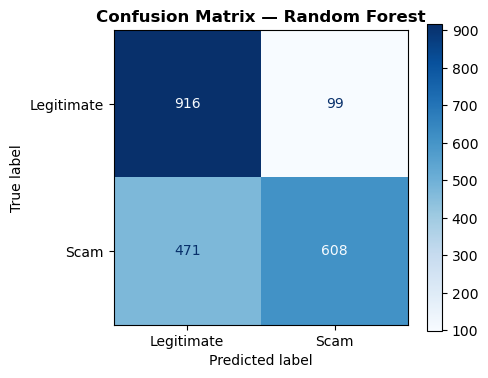

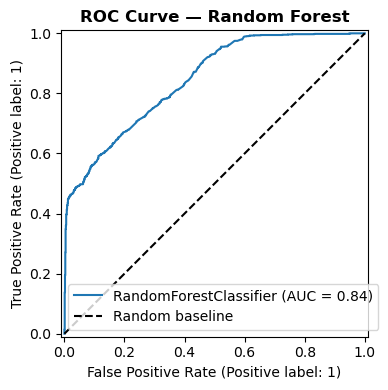

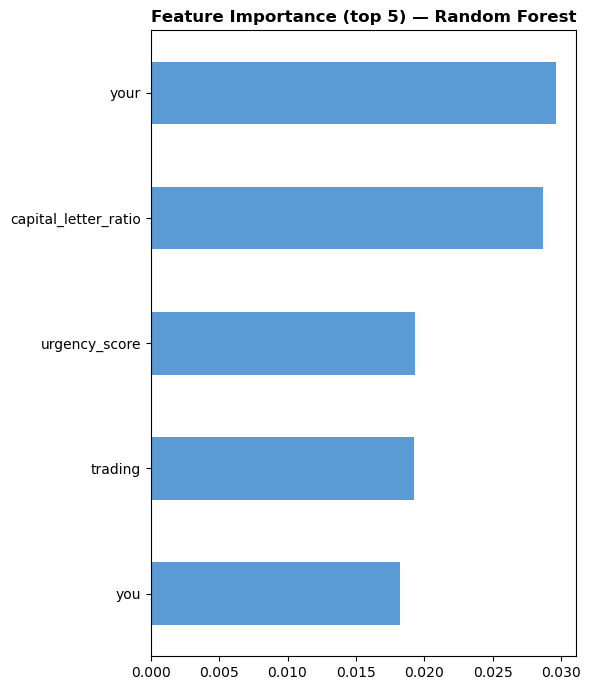

🏃 View run team03_s301_random_forest_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/bde4be2ef3004d0ab407756314246980
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RANDOM FOREST RESULTS
  TEST test_accuracy: 0.7278
  TEST test_auc_roc: 0.8446
  TEST test_f1: 0.6809
  TEST test_precision: 0.86
  TEST test_recall: 0.5635
  TRAIN train_accuracy: 0.7388
  TRAIN train_auc_roc: 0.8558
  TRAIN train_f1: 0.6867
  TRAIN train_precision: 0.8991
  TRAIN train_recall: 0.5555


In [8]:
from sklearn.ensemble import RandomForestClassifier

run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest_baseline"

RF_PARAMS = {'n_estimators':100,'max_depth':6,'min_samples_leaf':4,
             'random_state':RANDOM_STATE,'n_jobs':-1}

with mlflow.start_run(run_name=run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({**RF_PARAMS, 'model_type':'RandomForestClassifier',
                       'n_features':X_train.shape[1], 'train_size':X_train.shape[0]})

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_train, y_train)

    metrics = evaluate_model(rf, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(rf, X_test, y_test, 'Random Forest')
    log_roc_curve(rf, X_test, y_test, 'Random Forest')
    log_feature_importance(rf, FEATURE_NAMES, 'Random Forest')
    mlflow.sklearn.log_model(rf, name ='model')
    RF_RUN_ID = run.info.run_id

print('RANDOM FOREST RESULTS')
for k, v in sorted(metrics.items()):
    split = 'TRAIN' if k.startswith('train') else 'TEST'
    print(f'  {split} {k}: {v}')

**Key finding:** The Random Forest baseline reaches 0.8446 test AUC-ROC and only 56.35% recall, missing more scam messages than it catches even though precision stays high at 86.0%. A test AUC of 0.8446 also falls short of the 0.85 quality gate on its own, so this baseline alone would not pass approval. Since the proposal treats missed scams as more costly than false alarms, this recall drop is the clearest warning sign in the whole comparison and points to needing deeper trees or a different class-weighting strategy on this dataset.


## 7. Random Forest Hyperparameter Tuning

Each hyperparameter combination is logged as a child run under a parent run. This keeps the MLflow UI organised, with the parent summarising the best result.


In [9]:
param_grid = [
    {'n_estimators': 50,  'max_depth': 4, 'min_samples_leaf': 2},
    {'n_estimators':100,  'max_depth': 4, 'min_samples_leaf': 4},
    {'n_estimators':100,  'max_depth': 6, 'min_samples_leaf': 2},
    {'n_estimators':200,  'max_depth': 6, 'min_samples_leaf': 4},
    {'n_estimators':200,  'max_depth': 8, 'min_samples_leaf': 2},
]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_auc, best_model, best_params = 0, None, None

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_rf_tuning_parent") as parent:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_param('n_candidates', len(param_grid))
    mlflow.log_param('cv_folds', 5)

    for i, params in enumerate(param_grid):
        all_p = {**params, 'class_weight':'balanced', 'random_state':RANDOM_STATE}
        with mlflow.start_run(run_name=f'rf_candidate_{i+1:02d}', nested=True):
            
            mlflow.set_tags(COMMON_TAGS)
            mlflow.log_params(all_p)
            m = RandomForestClassifier(**all_p, n_jobs=-1)
            cv_scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
            mlflow.log_metric('cv_auc_mean', round(cv_scores.mean(),4))
            mlflow.log_metric('cv_auc_std',  round(cv_scores.std(),4))
            m.fit(X_train, y_train)
            test_m = evaluate_model(m, X_train, y_train, X_test, y_test)
            mlflow.log_metrics(test_m)
            mlflow.sklearn.log_model(m, name = "model")

            print(f'Candidate {i+1}: {params} | CV AUC={cv_scores.mean():.4f} | Test AUC={test_m["test_auc_roc"]}')
            if cv_scores.mean() > best_auc:
                best_auc, best_model, best_params = cv_scores.mean(), m, all_p

    mlflow.log_metric('best_cv_auc', round(best_auc,4))
    TUNING_RUN_ID = parent.info.run_id

print(f'\nBest CV AUC: {best_auc:.4f}')
print(f'Best params: {best_params}')

Candidate 1: {'n_estimators': 50, 'max_depth': 4, 'min_samples_leaf': 2} | CV AUC=0.7800 | Test AUC=0.7896
🏃 View run rf_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/153283e7e00a46eeb5f50190f1c0a083
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 2: {'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 4} | CV AUC=0.7986 | Test AUC=0.8219
🏃 View run rf_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/e110bfdb8ede4820843803d100221a72
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 3: {'n_estimators': 100, 'max_depth': 6, 'min_samples_leaf': 2} | CV AUC=0.8249 | Test AUC=0.8434
🏃 View run rf_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/774d06b58b8548a588aacdf0e7cca548
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 4: {'n_est

**Key finding:** Widening trees to 200 estimators, depth 8 and min_samples_leaf 2 lifts Random Forest from 0.8446 to 0.86 test AUC, the best of the five candidates tested and now just above the quality gate. CV AUC rises from 0.78 to 0.8451 as estimators and depth increase, the same pattern seen before, and recall for this candidate reaches 52.18% in the comparison below, an improvement over the baseline but still barely above half. Even after tuning, Random Forest still trails the logistic regression baseline's 0.8898 test AUC and its recall remains far below logistic regression's, so logistic regression remains the stronger candidate on this dataset.


## 8. Compare Runs and Register Best Model

Selects the best run for each model type on the current dataset version, compares them against the quality gate, and prepares the winning run for the next step.


In [10]:
from mlflow.tracking import MlflowClient
import mlflow

client = MlflowClient()

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)

if exp is None:
    raise ValueError(f"Experiment not found: {MLFLOW_EXPERIMENT}")

# Scoped to this notebook execution (run_session_id) and this dataset version
base_filter = (
    "attributes.status = 'FINISHED' "
    f"and tags.dataset_sha256 = '{DATASET_VERSION}' "
    f"and tags.run_session_id = '{RUN_SESSION_ID}'"
)

def best_run_for(name_filter, display_name):
    matches = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"{base_filter} and {name_filter}",
        order_by=["metrics.test_auc_roc DESC"],
    )
    if matches.empty:
        print(f"[WARNING] No finished run found for '{display_name}' on this dataset version.")
        return None
    row = matches.iloc[0].copy()
    row["display_name"] = display_name
    return row

lr_row = best_run_for(
    f"tags.mlflow.runName = '{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline'",
    "Logistic Regression (baseline)",
)
lr_tuned_row = best_run_for(
    "tags.mlflow.runName LIKE 'lr_candidate_%'",
    "Logistic Regression (tuned, best candidate)",
)
rf_row = best_run_for(
    f"tags.mlflow.runName = '{TEAM_ID}_{STUDENT_ID}_random_forest_baseline'",
    "Random Forest (baseline)",
)
rf_tuned_row = best_run_for(
    "tags.mlflow.runName LIKE 'rf_candidate_%'",
    "Random Forest (tuned, best candidate)",
)

selected = [r for r in [lr_row, lr_tuned_row, rf_row, rf_tuned_row] if r is not None]
if not selected:
    raise ValueError("None of the expected baseline/tuning runs were found for this dataset version.")

runs = pd.DataFrame(selected).reset_index(drop=True)

cols = [
    "display_name",
    "tags.mlflow.runName",
    "metrics.test_auc_roc",
    "metrics.test_accuracy",
    "metrics.test_f1",
    "metrics.test_recall",
    "run_id"
]

avail = [c for c in cols if c in runs.columns]
print(runs[avail].to_string(index=False))

best_run = runs.sort_values("metrics.test_auc_roc", ascending=False).iloc[0]
BEST_RUN_ID = best_run["run_id"]
BEST_AUC = best_run.get("metrics.test_auc_roc", 0)
BEST_RUN_NAME = best_run.get("tags.mlflow.runName", "unknown")

print(f"\nBest run: {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")

                               display_name                      tags.mlflow.runName  metrics.test_auc_roc  metrics.test_accuracy  metrics.test_f1  metrics.test_recall                           run_id
             Logistic Regression (baseline) team03_s301_logistic_regression_baseline                0.8898                 0.7713           0.7750               0.7646 3bc650c2f6344811a234d4a131179562
Logistic Regression (tuned, best candidate)                          lr_candidate_04                0.8908                 0.7751           0.7786               0.7674 414ab19db4ed4e69b21b13fdcb9bcef8
                   Random Forest (baseline)       team03_s301_random_forest_baseline                0.8446                 0.7278           0.6809               0.5635 bde4be2ef3004d0ab407756314246980
      Random Forest (tuned, best candidate)                          rf_candidate_05                0.8600                 0.7373           0.6718               0.5218 19377a5a5add477987ba7d77cea0

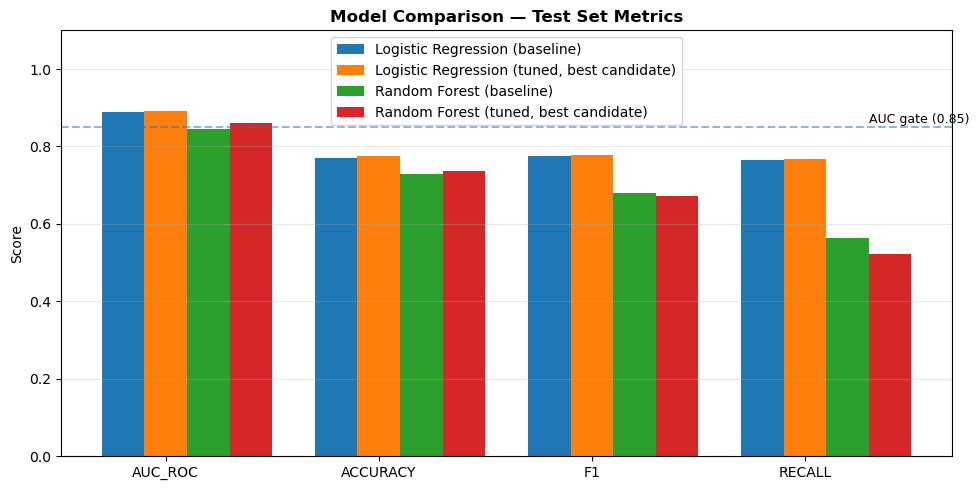

In [11]:
# Visual comparison of the four selected runs (LR baseline, LR tuned, RF baseline, RF tuned).
fig, ax = plt.subplots(figsize=(10,5))

metric_cols = [
    'metrics.test_auc_roc',
    'metrics.test_accuracy',
    'metrics.test_f1',
    'metrics.test_recall'
]
avail_m = [c for c in metric_cols if c in runs.columns]

top_runs = runs.head(4)
labels = [c.replace('metrics.test_','').upper() for c in avail_m]
x = np.arange(len(labels))
w = 0.2

for idx,(_, row) in enumerate(top_runs.iterrows()):
    vals = [row.get(m,0) for m in avail_m]
    ax.bar(
        x + idx*w,
        vals,
        w,
        label=row.get('display_name', row.get('tags.mlflow.runName', f'run{idx}'))
    )

ax.set_xticks(x+w)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontweight='bold')
ax.axhline(QUALITY_GATE, linestyle='--', alpha=0.5)
ax.text(len(labels)-0.5, QUALITY_GATE+0.01, f'AUC gate ({QUALITY_GATE})', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Key finding:** Across all four runs, the best-tuned logistic regression candidate now narrowly leads at 0.8908 test AUC-ROC and 76.74% recall, just ahead of the logistic regression baseline's 0.8898 AUC, with both Random Forest runs trailing on every metric and the Random Forest baseline missing the quality gate outright at 0.8446. The overall winner is lr_candidate_04, C=10.0 with an L2 penalty, though its margin over the baseline is small enough that either logistic regression run would be a reasonable choice.

Logistic regression's edge likely comes from the feature space: TF-IDF is high-dimensional and sparse, a setting linear models handle well, while Random Forest needs more data per split to work across thousands of sparse columns, which shows up most in its much lower recall (52.18% vs 76.74%). 

It's also worth noting this is a synthetic dataset rather than real-world scam messages, so word patterns and class boundaries may be more linearly separable and more consistent than genuine data would be. That plays to logistic regression's strengths and may be inflating its advantage over Random Forest here, so the gap could narrow or shift on real-world messages.

In [12]:
# Quality Gate and Best Model Selection
print("QUALITY GATE")

if BEST_AUC < QUALITY_GATE:

    print(f"Quality gate FAILED")
    print(f"Best AUC: {BEST_AUC:.4f}")
    print(f"Required: {QUALITY_GATE:.2f}")
    print("\nReview feature engineering or hyperparameters before proceeding.")

    BEST_MODEL_URI = None

else:

    print(f"Quality gate PASSED")
    print(f"Best AUC: {BEST_AUC:.4f}")

    # Export best model info
    BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"

    print("\nBest MLflow Run")
    print(f"Run Name: {BEST_RUN_NAME}")
    print(f"Run ID: {BEST_RUN_ID}")
    print(f"Model URI: {BEST_MODEL_URI}")
    print(f"Best AUC: {BEST_AUC:.4f}")


QUALITY GATE
Quality gate PASSED
Best AUC: 0.8908

Best MLflow Run
Run Name: lr_candidate_04
Run ID: 414ab19db4ed4e69b21b13fdcb9bcef8
Model URI: runs:/414ab19db4ed4e69b21b13fdcb9bcef8/model
Best AUC: 0.8908


In [13]:
# Persist best model info to JSON for downstream use.
import json

best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_auc": float(BEST_AUC),
    "best_model_uri": BEST_MODEL_URI,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

print("Saved best model information to best_model.json")
print(json.dumps(best_model_info, indent=2))

Saved best model information to best_model.json
{
  "team_id": "team03",
  "student_id": "s301",
  "project_name": "crypto-scam-detector",
  "best_run_id": "414ab19db4ed4e69b21b13fdcb9bcef8",
  "best_run_name": "lr_candidate_04",
  "best_auc": 0.8908,
  "best_model_uri": "runs:/414ab19db4ed4e69b21b13fdcb9bcef8/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW",
  "mlflow_experiment": "ITI113/team03/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team03"
}


In [14]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
artifacts = client.list_artifacts(BEST_RUN_ID)

for a in artifacts:
    print(a.path, a.is_dir)

In [15]:
# Load best model directly from the best MLflow run and test inference
loaded = mlflow.sklearn.load_model(BEST_MODEL_URI)
sample = X_test[:5]
preds = loaded.predict(sample)
probas = loaded.predict_proba(sample)[:, 1]

results = pd.DataFrame({
    "actual": y_test.head(5).values,
    "predicted": preds,
    "probability": probas.round(3),
    "correct": preds == y_test.head(5).values
})

print("Sample predictions from best MLflow run model:")
print(results.to_string(index=False))

Sample predictions from best MLflow run model:
 actual  predicted  probability  correct
      1          1        0.967     True
      0          1        0.685    False
      0          0        0.019     True
      1          1        0.992     True
      1          1        0.577     True


In [16]:
print(f"Experiment: {MLFLOW_EXPERIMENT}")
print(f"MLflow App: {MLFLOW_APP_ARN}")
print(f"Best model: {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")
print(f"Best run ID: {BEST_RUN_ID}")
print(f"Model URI: {BEST_MODEL_URI}")

Experiment: ITI113/team03/Experiment1
MLflow App: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW
Best model: lr_candidate_04 | AUC=0.8908
Best run ID: 414ab19db4ed4e69b21b13fdcb9bcef8
Model URI: runs:/414ab19db4ed4e69b21b13fdcb9bcef8/model


## Download model if needed

Reloads the best model from MLflow using best_model.json and saves a local copy of the model artifact folder, useful for offline inspection or manual upload steps.


In [17]:
# Find MLflow model URI, load model, and download model artifact for SageMaker MLflow App / Serverless MLflow

import os
import json
from pathlib import Path

import mlflow
import mlflow.sklearn

# Load best model information saved above
BEST_MODEL_JSON = "best_model.json"

if not os.path.exists(BEST_MODEL_JSON):
    raise FileNotFoundError(
        f"{BEST_MODEL_JSON} not found. "
        "Run the model selection cell first."
    )

with open(BEST_MODEL_JSON, "r") as f:
    best_model_info = json.load(f)

print("Best model information:")
print(json.dumps(best_model_info, indent=2))

# Set MLflow tracking URI
mlflow_tracking_uri = best_model_info["mlflow_tracking_uri"]
best_model_uri = best_model_info["best_model_uri"]
best_run_id = best_model_info["best_run_id"]

mlflow.set_tracking_uri(mlflow_tracking_uri)

print("\nMLflow tracking URI:")
print(mlflow_tracking_uri)

print("\nBest run ID:")
print(best_run_id)

print("\nBest model URI:")
print(best_model_uri)

# Load the model directly from MLflow
loaded_model = mlflow.sklearn.load_model(best_model_uri)

print("\nLoaded model type:")
print(type(loaded_model))

# Download the MLflow model artifact folder locally
download_dir = Path("downloaded_mlflow_models")
download_dir.mkdir(parents=True, exist_ok=True)

local_model_path = mlflow.artifacts.download_artifacts(
    artifact_uri=best_model_uri,
    dst_path=str(download_dir)
)

print("\nDownloaded model folder:")
print(local_model_path)

# List downloaded model files
print("\nDownloaded files:")

for root, dirs, files in os.walk(local_model_path):
    level = root.replace(local_model_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        file_path = os.path.join(root, file)
        size_bytes = os.path.getsize(file_path)
        print(f"{indent}  {file}  ({size_bytes} bytes)")

Best model information:
{
  "team_id": "team03",
  "student_id": "s301",
  "project_name": "crypto-scam-detector",
  "best_run_id": "414ab19db4ed4e69b21b13fdcb9bcef8",
  "best_run_name": "lr_candidate_04",
  "best_auc": 0.8908,
  "best_model_uri": "runs:/414ab19db4ed4e69b21b13fdcb9bcef8/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW",
  "mlflow_experiment": "ITI113/team03/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team03"
}

MLflow tracking URI:
arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW

Best run ID:
414ab19db4ed4e69b21b13fdcb9bcef8

Best model URI:
runs:/414ab19db4ed4e69b21b13fdcb9bcef8/model



Loaded model type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>



Downloaded model folder:
/home/sagemaker-user/team03/downloaded_mlflow_models/model

Downloaded files:
model/
  MLmodel  (740 bytes)
  conda.yaml  (350 bytes)
  model.skops  (49613 bytes)
  python_env.yaml  (123 bytes)
  requirements.txt  (200 bytes)
  registered_model_meta  (37 bytes)
